# Project 2: Customer Segmentation & RFM Analysis
## Notebook 3: Business Recommendations

**Tujuan:** Mengubah hasil clustering menjadi insight bisnis yang actionable.  


---
## Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f8f9fa',
    'axes.grid'       : True,
    'grid.color'      : 'white',
    'grid.linewidth'  : 1.2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

seg_order  = ['Champions', 'Loyal Customers', 'At Risk', 'Lost Customers']
seg_colors = dict(zip(seg_order, ['#2A9D8F', '#E9C46A', '#E76F51', '#264653']))

rfm = pd.read_csv('rfm_clustered.csv')
print('Data loaded!')
print(f'Total pelanggan: {len(rfm):,}')
print(rfm['Segment'].value_counts().to_string())

Data loaded!
Total pelanggan: 4,338
Segment
Champions          1312
Lost Customers     1182
At Risk             968
Loyal Customers     876


---
## Revenue Analysis per Segmen — Pareto Principle

Statistik per Segmen


,N_Customers,Total_Rev,Avg_Rev,Avg_Recency,Avg_Freq,Pct_Customers,Pct_Revenue
Segment,,,,,,,
Champions,1312,6692732.94,5101.17,16.65,9.52,30.2,75.3
Loyal Customers,876,1417185.79,1617.79,108.19,3.49,20.2,15.9
At Risk,968,389956.46,402.85,31.96,1.57,22.3,4.4
Lost Customers,1182,387351.70,327.71,214.78,1.24,27.2,4.4


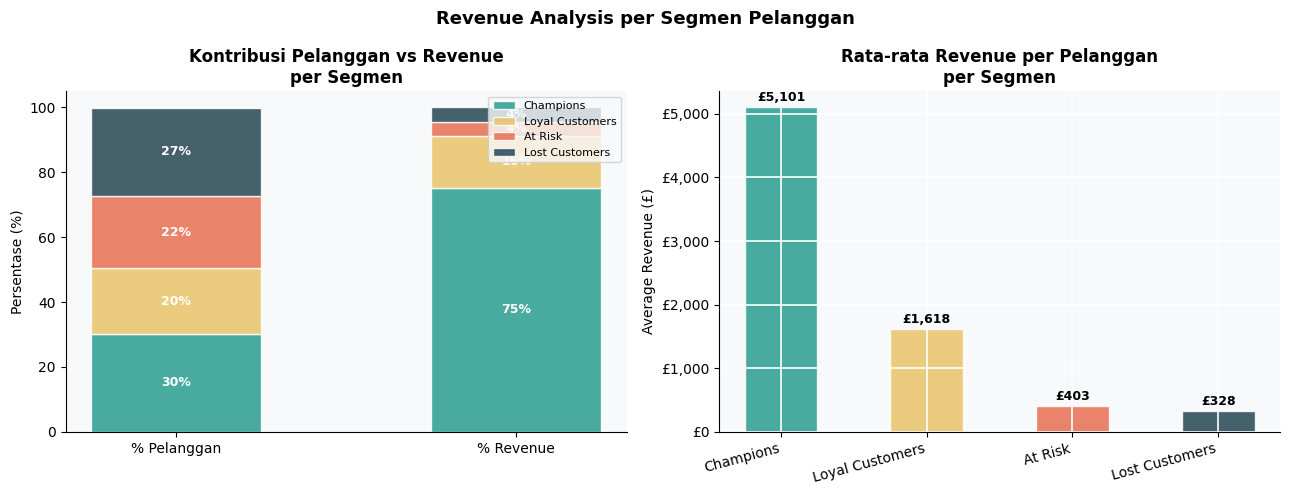

In [2]:
# Hitung kontribusi revenue per segmen
seg_stats = rfm.groupby('Segment').agg(
    N_Customers  = ('Customer ID', 'count'),
    Total_Rev    = ('Monetary', 'sum'),
    Avg_Rev      = ('Monetary', 'mean'),
    Avg_Recency  = ('Recency',  'mean'),
    Avg_Freq     = ('Frequency','mean'),
).reindex(seg_order).round(2)

seg_stats['Pct_Customers'] = (seg_stats['N_Customers'] / seg_stats['N_Customers'].sum() * 100).round(1)
seg_stats['Pct_Revenue']   = (seg_stats['Total_Rev']   / seg_stats['Total_Rev'].sum()   * 100).round(1)

print('Statistik per Segmen')
display(seg_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar: pelanggan vs revenue
x = np.arange(2)
bottom_cust = 0
bottom_rev  = 0
for seg in seg_order:
    pct_c = seg_stats.loc[seg, 'Pct_Customers']
    pct_r = seg_stats.loc[seg, 'Pct_Revenue']
    axes[0].bar(0, pct_c, bottom=bottom_cust, color=seg_colors[seg],
                alpha=0.85, edgecolor='white', width=0.5, label=seg)
    axes[0].bar(1, pct_r, bottom=bottom_rev,  color=seg_colors[seg],
                alpha=0.85, edgecolor='white', width=0.5)
    if pct_c > 3:
        axes[0].text(0, bottom_cust + pct_c/2, f'{pct_c:.0f}%', ha='center',
                     va='center', fontsize=9, fontweight='bold', color='white')
    if pct_r > 3:
        axes[0].text(1, bottom_rev + pct_r/2, f'{pct_r:.0f}%', ha='center',
                     va='center', fontsize=9, fontweight='bold', color='white')
    bottom_cust += pct_c
    bottom_rev  += pct_r

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['% Pelanggan', '% Revenue'])
axes[0].set_ylabel('Persentase (%)')
axes[0].set_title('Kontribusi Pelanggan vs Revenue\nper Segmen', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(False)

# Average Revenue per Customer per segmen
bars = axes[1].bar(
    seg_order,
    seg_stats['Avg_Rev'].values,
    color=[seg_colors[s] for s in seg_order],
    alpha=0.85, edgecolor='white', width=0.5
)
for bar, val in zip(bars, seg_stats['Avg_Rev'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + seg_stats['Avg_Rev'].max()*0.01,
                 f'£{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Rata-rata Revenue per Pelanggan\nper Segmen', fontweight='bold')
axes[1].set_ylabel('Average Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].set_xticklabels(seg_order, rotation=15, ha='right')

plt.suptitle('Revenue Analysis per Segmen Pelanggan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_08_revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Business Recommendations per Segmen

In [3]:
recommendations = {
    'Champions': {
        'emoji'      : '🏆',
        'deskripsi'  : 'Pelanggan terbaik: beli baru-baru ini, sering, dan nilai besar.',
        'strategi'   : [
            'Berikan reward eksklusif & loyalty program (early access, VIP tier)',
            'Minta review / testimoni produk — mereka paling terpercaya',
            'Tawarkan produk premium atau upsell kategori baru',
            'Program referral: ajak mereka merekomendasikan ke teman',
        ],
        'tujuan'     : 'Pertahankan loyalitas & jadikan brand ambassador',
        'metrik'     : 'Repeat purchase rate, referral conversion'
    },
    'Loyal Customers': {
        'emoji'      : '💛',
        'deskripsi'  : 'Pelanggan setia dengan frekuensi tinggi, tapi monetary belum optimal.',
        'strategi'   : [
            'Cross-sell: rekomendasikan produk komplementer dari history beli',
            'Bundle offer: paket produk dengan diskon lebih hemat',
            'Anniversary reward: hadiah di bulan pertama mereka bergabung',
            'Nudge ke kategori premium — mereka sudah percaya brand kita',
        ],
        'tujuan'     : 'Tingkatkan average order value (AOV)',
        'metrik'     : 'Average order value, cross-sell rate'
    },
    'At Risk': {
        'emoji'      : '⚠️',
        'deskripsi'  : 'Dulu aktif, tapi belakangan tidak beli. Perlu segera diactivate ulang.',
        'strategi'   : [
            'Win-back email: "Kami kangen kamu!" + diskon personal 15-20%',
            'Survei singkat: tanya kenapa mereka berhenti beli',
            'Tampilkan produk baru yang relevan dengan history pembelian',
            'Flash sale eksklusif dengan deadline waktu (urgency)',
        ],
        'tujuan'     : 'Reaktivasi sebelum benar-benar churn',
        'metrik'     : 'Reactivation rate, win-back conversion'
    },
    'Lost Customers': {
        'emoji'      : '😴',
        'deskripsi'  : 'Sudah lama tidak aktif, nilai pembelian rendah, frekuensi rendah.',
        'strategi'   : [
            'Last-chance offer: diskon besar sekali untuk coba pulihkan',
            'Jika tidak respons dalam 30 hari, pertimbangkan unsubscribe dari mailing list',
            'Fokus budget marketing ke segmen lain yang lebih potential',
            'Analisis kenapa mereka hilang untuk perbaiki produk/layanan',
        ],
        'tujuan'     : 'Minimasi biaya, fokus pada segmen lebih profitable',
        'metrik'     : 'Recovery rate, cost per reactivation'
    }
}

for seg in seg_order:
    rec = recommendations[seg]
    n   = len(rfm[rfm['Segment'] == seg])
    pct = n / len(rfm) * 100
    print(f"{rec['emoji']} {seg.upper()} ({n:,} pelanggan, {pct:.1f}%)")
    print(f"   📌 {rec['deskripsi']}")
    print(f"   🎯 Tujuan: {rec['tujuan']}")
    print(f"   📊 Metrik: {rec['metrik']}")
    print('   Strategi:')
    for s in rec['strategi']:
        print(f'      • {s}')
    print()

🏆 CHAMPIONS (1,312 pelanggan, 30.2%)
   📌 Pelanggan terbaik: beli baru-baru ini, sering, dan nilai besar.
   🎯 Tujuan: Pertahankan loyalitas & jadikan brand ambassador
   📊 Metrik: Repeat purchase rate, referral conversion
   Strategi:
      • Berikan reward eksklusif & loyalty program (early access, VIP tier)
      • Minta review / testimoni produk — mereka paling terpercaya
      • Tawarkan produk premium atau upsell kategori baru
      • Program referral: ajak mereka merekomendasikan ke teman

💛 LOYAL CUSTOMERS (876 pelanggan, 20.2%)
   📌 Pelanggan setia dengan frekuensi tinggi, tapi monetary belum optimal.
   🎯 Tujuan: Tingkatkan average order value (AOV)
   📊 Metrik: Average order value, cross-sell rate
   Strategi:
      • Cross-sell: rekomendasikan produk komplementer dari history beli
      • Bundle offer: paket produk dengan diskon lebih hemat
      • Anniversary reward: hadiah di bulan pertama mereka bergabung
      • Nudge ke kategori premium — mereka sudah percaya brand kit

---
## Visualisasi Rekomendasi — Marketing Priority Matrix

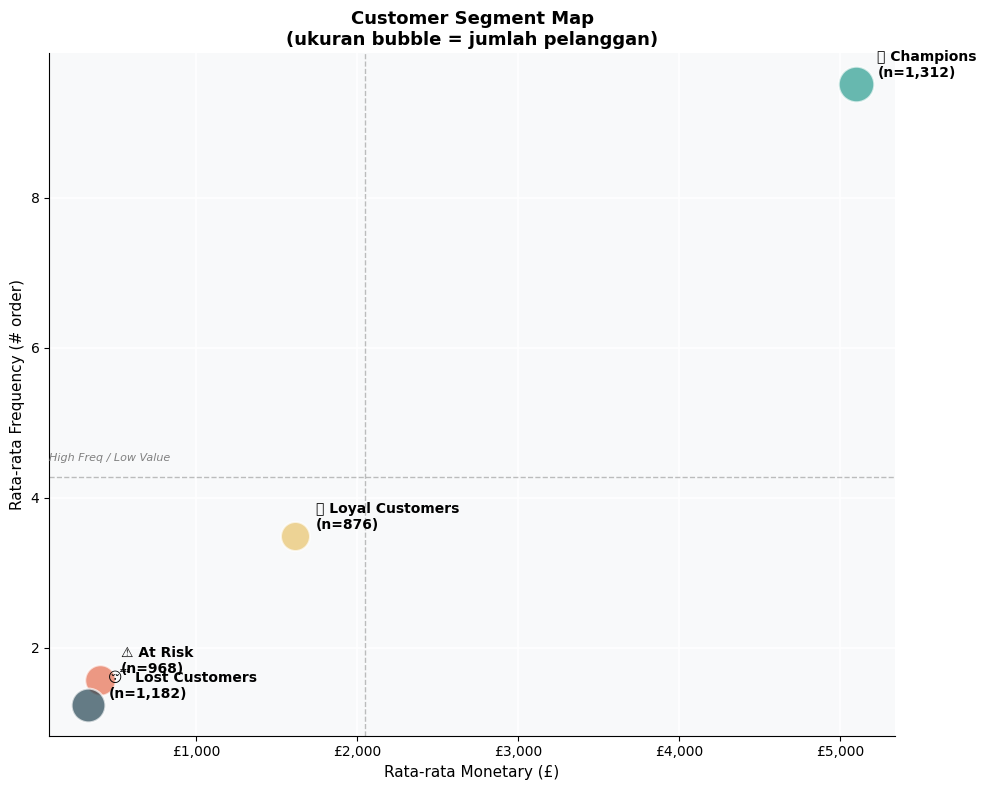

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

# Sumbu X = avg monetary, Y = avg frequency, size = jumlah pelanggan
for seg in seg_order:
    s    = rfm[rfm['Segment'] == seg]
    x    = s['Monetary'].mean()
    y    = s['Frequency'].mean()
    size = len(s) * 0.5
    ax.scatter(x, y, s=size, color=seg_colors[seg], alpha=0.7,
               edgecolors='white', linewidths=1.5, zorder=3)
    ax.annotate(
        f"{recommendations[seg]['emoji']} {seg}\n(n={len(s):,})",
        (x, y),
        textcoords='offset points',
        xytext=(15, 5),
        fontsize=10,
        fontweight='bold'
    )

# Garis median sebagai threshold
med_x = rfm['Monetary'].mean()
med_y = rfm['Frequency'].mean()
ax.axvline(med_x, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(med_y, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Label kuadran
ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else med_x*0.1,
        med_y * 1.05, 'High Freq / Low Value', fontsize=8,
        color='gray', style='italic')

ax.set_xlabel('Rata-rata Monetary (£)', fontsize=11)
ax.set_ylabel('Rata-rata Frequency (# order)', fontsize=11)
ax.set_title(
    'Customer Segment Map\n(ukuran bubble = jumlah pelanggan)',
    fontweight='bold', fontsize=13
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('plot_09_segment_map.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Export Daftar Pelanggan per Segmen

In [5]:
# Export untuk tim marketing — siap dipakai
output_cols = ['Customer ID', 'Segment', 'Recency', 'Frequency', 'Monetary',
               'R_Score', 'F_Score', 'M_Score', 'RFM_Total']

for seg in seg_order:
    seg_df = rfm[rfm['Segment'] == seg][output_cols].sort_values('Monetary', ascending=False)
    fname  = f"customers_{seg.lower().replace(' ', '_')}.csv"
    seg_df.to_csv(fname, index=False)
    print(f'Tersimpan: {fname}  ({len(seg_df):,} pelanggan)')

# Export semua sekaligus
rfm[output_cols].sort_values(['Segment','Monetary'], ascending=[True, False])\
                .to_csv('all_customers_segmented.csv', index=False)
print('\nFile lengkap: all_customers_segmented.csv')

Tersimpan: customers_champions.csv  (1,312 pelanggan)
Tersimpan: customers_loyal_customers.csv  (876 pelanggan)
Tersimpan: customers_at_risk.csv  (968 pelanggan)
Tersimpan: customers_lost_customers.csv  (1,182 pelanggan)

File lengkap: all_customers_segmented.csv


---
## Ringkasan Eksekutif (Executive Summary)

In [6]:
total_rev   = rfm['Monetary'].sum()
champ       = rfm[rfm['Segment'] == 'Champions']
at_risk     = rfm[rfm['Segment'] == 'At Risk']

print('   EXECUTIVE SUMMARY — CUSTOMER SEGMENTATION')
print(f"""
KONTEKS
   Analisis {len(rfm):,} pelanggan dari data transaksi retail
   menggunakan metode RFM + K-Means Clustering (K=4).

TEMUAN UTAMA
   1. Champions ({len(champ):,} pelanggan, {len(champ)/len(rfm)*100:.1f}%) menyumbang
      {champ['Monetary'].sum()/total_rev*100:.1f}% dari total revenue.
      → Prioritas utama untuk dipertahankan.

   2. At Risk ({len(at_risk):,} pelanggan) pernah aktif tapi mulai
      menjauh. Potensi revenue hilang: £{at_risk['Monetary'].sum():,.0f}
      → Perlu win-back campaign segera.

   3. Prinsip Pareto terkonfirmasi: ~{len(champ)/len(rfm)*100:.0f}% pelanggan
      (Champions) menghasilkan {champ['Monetary'].sum()/total_rev*100:.0f}%+ revenue.

REKOMENDASI PRIORITAS
   Tinggi   : Pertahankan Champions dengan loyalty program
   Sedang   : Reaktivasi At Risk dengan win-back campaign
   Rendah   : Upsell Loyal Customers ke produk premium
   Monitor  : Evaluasi cost untuk Lost Customers

NEXT STEPS
   → Deploy dashboard Streamlit untuk monitoring real-time
   → A/B test win-back email campaign untuk At Risk
   → Review ulang segmen setiap 3 bulan
""")

   EXECUTIVE SUMMARY — CUSTOMER SEGMENTATION

KONTEKS
   Analisis 4,338 pelanggan dari data transaksi retail
   menggunakan metode RFM + K-Means Clustering (K=4).

TEMUAN UTAMA
   1. Champions (1,312 pelanggan, 30.2%) menyumbang
      75.3% dari total revenue.
      → Prioritas utama untuk dipertahankan.

   2. At Risk (968 pelanggan) pernah aktif tapi mulai
      menjauh. Potensi revenue hilang: £389,956
      → Perlu win-back campaign segera.

   3. Prinsip Pareto terkonfirmasi: ~30% pelanggan
      (Champions) menghasilkan 75%+ revenue.

REKOMENDASI PRIORITAS
   Tinggi   : Pertahankan Champions dengan loyalty program
   Sedang   : Reaktivasi At Risk dengan win-back campaign
   Rendah   : Upsell Loyal Customers ke produk premium
   Monitor  : Evaluasi cost untuk Lost Customers

NEXT STEPS
   → Deploy dashboard Streamlit untuk monitoring real-time
   → A/B test win-back email campaign untuk At Risk
   → Review ulang segmen setiap 3 bulan

